# Линейная регрессия

## Сегодня на практическом занятии:
1. Узнаем, какое количество весов нужно обучать для линейной модели
2. Обучим модель линейной регрессии из sklearn
3. Визуализируем линейную регрессию из sklearn
4. Реализуем свой градиентный спуск для нахождения минимума функции
5. Реализуем свою линейную регрессию с помощью градиентного спуска

### Получение данных

Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [5]:
data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


## 1. Вводная

В этом пункте вспомним, что такое веса в линейной модели.

### 1.1 Сколько будет обучено свободных весов

Сколько будет создано свободных весов в модели линейная регрессия?

In [6]:
# 1 свободный вес

### 1.2 Сколько будет обучено весов при признаках

Посчитайте, сколько будет создано весов при признаках при обучении линейно модели.

In [7]:
# Напишите ответ на вопрос здесь. Можно посчитать вручную количество призниаков или использовать функцию X.shape
X.shape[1]

8

### 1.3 Обучите линейную модель для предсказания стоимости

In [8]:
# Ваш код здесь. Выставьте параметр fit_intercept (отвечает за то, нужно ли включать в модель свободный член) в false. 
# Последней строчкой должно быть применение метода .fit
model = LinearRegression(fit_intercept=False)
model.fit(X, y)

LinearRegression(fit_intercept=False)

### 1.4 Посмотрите, сколько вышло весов при признаках и свободных членов и сравните с вашими ответами

In [9]:
# Ваш код здесь. Напоминаю, что model.intercept_ - это свободный член, model.coef_ - веса
model_b_0 = model.intercept_
model_b_1 = model.coef_

model_b_0, len(model_b_1)

(0.0, 8)

## 2. Получение предсказаний линейной модели

В этом пункте вспомним, как получать предсказания линейной моделью.

### 2.1 Получите предсказание для одного объекта через метод модели

In [10]:
# Ваш код здесь. Сделайте предсказание по первому объекту вектора X
model.predict(X[:1]).item(), y[0]

(4.098399778940811, np.float64(4.526))

### 2.2 Получите предсказание для одного объекта через полученные веса

In [11]:
# Ваш код здесь
result = (model.coef_ * X[:1]).sum(axis=1)

result

0    4.0984
dtype: float64

### 2.3 Посмотрите ошибку MSE на предсказаниях модели

In [12]:
# Ваш код здесь
y_prediction = model.predict(X)

mean_squared_error(y, y_prediction)

0.6042095028861159

$$MSE = \frac{1}{n}\sum_i^n{(y - y_{pred})^2}$$

In [13]:
mse = ((y - y_prediction)**2).mean()

mse

np.float64(0.6042095028861159)

## 3. Визуализация линейной модели

В этом пункте провизуализируем линейную модель для одного признака.

### 3.1. Возьмите только один первый признак из данных и первые 1000 объектов

Назовите данный датафрейм `small_X`, а истинные значения `small_y`

In [14]:
# Ваш код здесь. Первый призак, очевидно, 'MedInc'. Вам может понадобиться метод iloc.
small_X = X['MedInc'].iloc[:1000]
small_y = y[:1000]

### 3.2. Обучите на этих данных линейную модель

In [15]:
# Ваш код здесь
small_model = LinearRegression(fit_intercept=False)

small_model.fit(np.array(small_X).reshape(-1, 1), small_y)


LinearRegression(fit_intercept=False)

### 3.3. Отобразите на графике обученную линейную регрессию

Добавьте на график точки из обучения в виде точечного графика

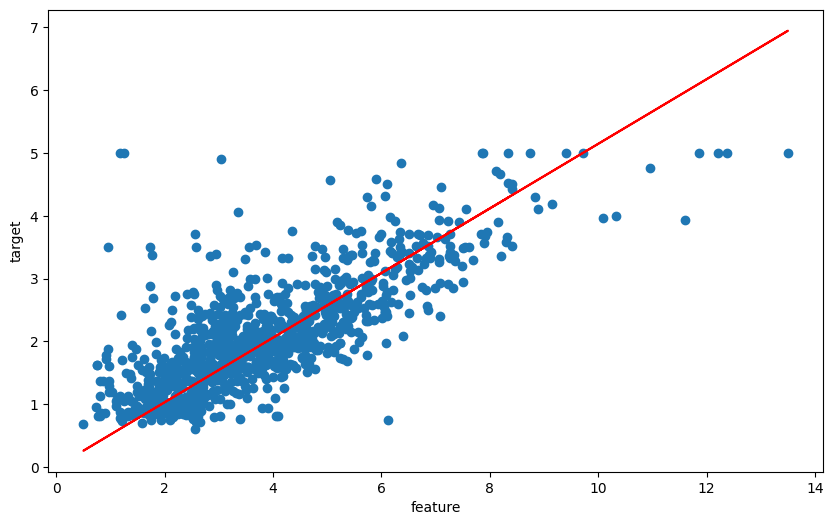

In [16]:
# Ваш код здесь
small_y_prediction = small_model.predict(np.array(small_X).reshape(-1, 1))

fig = plt.figure(figsize=(10, 6))
plt.scatter(small_X, small_y)

plt.plot(small_X, small_y_prediction, color="r")

plt.xlabel('feature')
plt.ylabel('target')
plt.show()

### 3.4 Посмотрите ошибку MSE на предсказаниях модели

In [17]:
# Ваш код здесь


mean_squared_error(small_y, small_y_prediction)

0.4026046814413365

In [18]:
small_y_prediction_all_array = small_model.predict(np.array(X['MedInc']).reshape(-1, 1)) # Для всего массива

mean_squared_error(y, small_y_prediction_all_array)

0.7407391761925747

## 4. Градиентный спуск

В этом пункте реализуем свой градиентный спуск.

### 4.1. Найдите градиент функции $z = 2x + y^2$

Ваш градиент здесь



In [19]:
# Градиентом функции f называется n-мерный вектор из частных производных.
def gr_func_1(y):
    dz_dx = 2
    dz_dy = 2 * y
    return dz_dx, dz_dy

### 4.2. Реализуйте функцию для подсчета $z = 0.25 x^2 + 5$

In [20]:
# Ваш код здесь
def func(x):
    return 0.25 * x**2 + 5

### 4.3. Реализуйте функцию для подсчета градиента $z = 0.25 x^2 + 5$

In [21]:
# Ваш код здесь
def gr_func(x):
    dz_dx = 0.5 * x 
    return dz_dx

### 4.4. Отрисуйте на графике функцию из пункта 4.2.

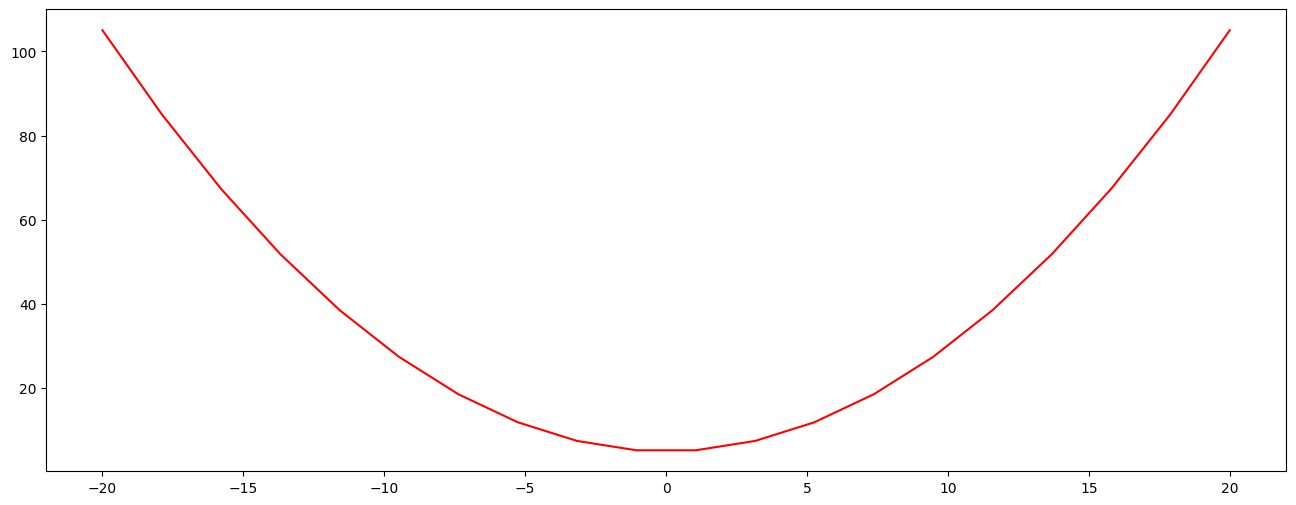

In [22]:
# Ваш код здесь
D = 20

X = np.linspace(-D, +D, 20)
Y = func(X)

plt.figure(figsize=(16, 6))
plt.plot(X, Y, 'r', label='Y(X)');

### 4.5. Задайте начальную точку равную -15 и посчитайте в ней градиент

In [23]:
# Ваш код здесь
start_point = -15
gradient = gr_func(start_point)

gradient

-7.5

### 4.5. Сделайте один шаг градиентного спуска и получите следующую точку для подсчета градиента

In [24]:
# Ваш код здесь
def go_step_to_min(x):
    return x - gr_func(x)

current_point = go_step_to_min(start_point)

current_point

-7.5

### 4.6. Оформите цикл из 10 шагов градиентного спуска

In [25]:
# Ваш код здесь
for i in range(10):
    current_point = go_step_to_min(current_point)
    next_point = go_step_to_min(current_point)
    print(f"Итерация: {i}")
    print(f"Текущая точка {current_point}| Следующая точка {next_point}")

Итерация: 0
Текущая точка -3.75| Следующая точка -1.875
Итерация: 1
Текущая точка -1.875| Следующая точка -0.9375
Итерация: 2
Текущая точка -0.9375| Следующая точка -0.46875
Итерация: 3
Текущая точка -0.46875| Следующая точка -0.234375
Итерация: 4
Текущая точка -0.234375| Следующая точка -0.1171875
Итерация: 5
Текущая точка -0.1171875| Следующая точка -0.05859375
Итерация: 6
Текущая точка -0.05859375| Следующая точка -0.029296875
Итерация: 7
Текущая точка -0.029296875| Следующая точка -0.0146484375
Итерация: 8
Текущая точка -0.0146484375| Следующая точка -0.00732421875
Итерация: 9
Текущая точка -0.00732421875| Следующая точка -0.003662109375


### 4.7. Визуализируйте шаги градиентного спуска на графике

Так же отрисуйте исходную функцию.

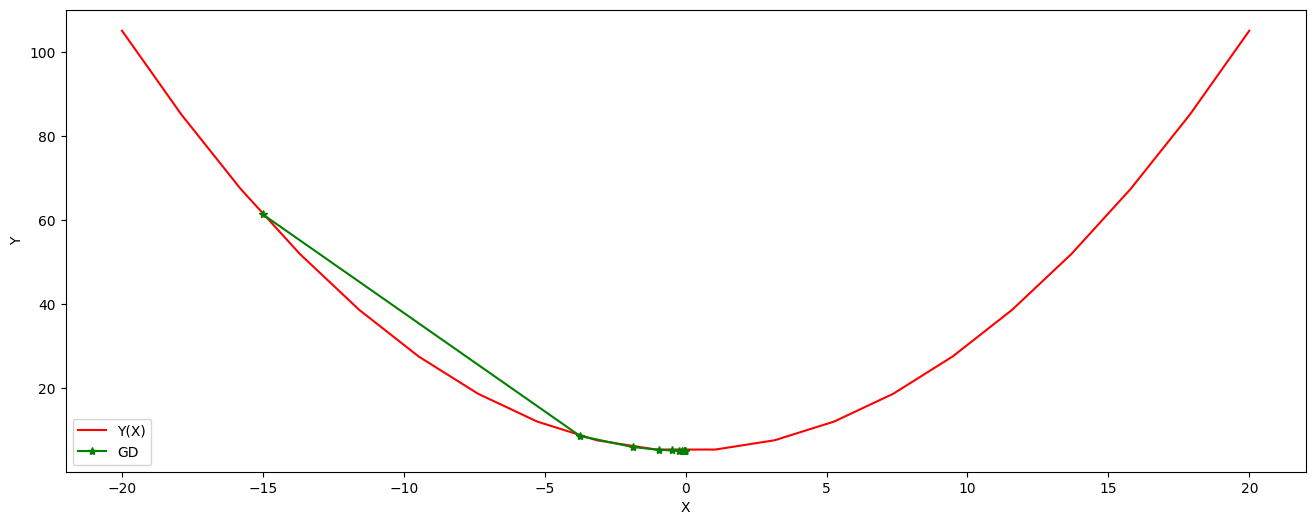

In [26]:
# Ваш код здесь
start_point = -15
current_point = go_step_to_min(start_point)

plt.figure(figsize=(16, 6))
plt.plot(X, Y, 'r', label='Y(X)')

learn_points = [start_point]


for i in range(10):
    current_point = go_step_to_min(current_point)
    next_point = go_step_to_min(current_point)
    learn_points.append(current_point)

X_grad = np.array(learn_points)
plt.plot(X_grad, func(X_grad), '-*g', label = 'GD')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


## 5. Многомерная линейная регрессия

В это пункте реализуем свою линейную регрессию для датафрейма small_X

#### 5.1 Реализуйте функцию для подсчета MSE

Функция на вход принимает матрицу `X`, вектор весов `w` и истинные значения `y`

In [27]:
# Ваш код здесь
def calculate_mse(X, w, y):
    y_pred = w[0] * X + w[1]
    return np.sum((y - y_pred) ** 2) / len(y_pred)

#### 5.2 Реализуйте функцию для подсчета градиента MSE

Функция на вход принимает матрицу `X`, вектор весов `w` и истинные значения `y`.

In [28]:
# Ваш код здесь

def gr_mse(X, w, y):
    y_pred = w[0] * X + w[1]
    return np.array( [((-2 / len(X)) * np.sum((y - y_pred) * X) ), ((-2 / len(X))* np.sum(y - y_pred))] )


#### 5.3 Инициализируйте веса для признаков

Вспомните и про свободный вес, что нужно сделать с данными, чтобы свободный вес не стоял отдельно.

In [29]:
# Ваш код здесь
arr_X = np.array(small_X)
arr_y = np.array(small_y)
w = np.array([0, 0])

print(calculate_mse(arr_X, w, arr_y))
print(gr_mse(arr_X, w, arr_y))

5.181785862001199
[-18.57380352  -4.19037224]


#### 5.4 Запустить цикл обучения через градиентный спуск для линейной регрессии


In [30]:
#@title Подсказка 1
# Вспомните про шаг обучения, если вам кажется, что он нужен

In [31]:
#@title Подсказка 2
# Возможно потребуется больше итераций (много тысяч)

In [32]:
# Ваш код здесь
learn_speed = 0.01

def go_step_to_min(X, w, y):
    grad = gr_mse(X, w, y) * learn_speed
    return np.array([w[0] - grad[0], w[1] - grad[1]])

print(calculate_mse(arr_X, w, arr_y))

n = 100000
for i in range(n):
    w = go_step_to_min(arr_X, w, arr_y)

print(f"result MSE: {calculate_mse(arr_X, w, arr_y)}")

5.181785862001199
result MSE: 0.326560551107268


#### 5.5 Реализуйте критерий останова по ошибке

Если ошибка с текущей итерации меньше, чем на следующей итерации, то можно выходить из цикла обучения


In [33]:
# Ваш код здесь
w = np.array([0, 0])
mse = calculate_mse(arr_X, w, arr_y)

n = 100000
for i in range(n):
    w = go_step_to_min(arr_X, w, arr_y)

    current_mse = calculate_mse(arr_X, w, arr_y)
    if mse < current_mse: break
    else: mse = current_mse

print(f"result MSE: {calculate_mse(arr_X, w, arr_y)}")

result MSE: 0.32656055110727267


## Резюме

Сегодня на практическом занятии:
1. Узнали, какое количество весов нужно обучать для линейной модели
2. Обучили модель линейной регрессии из sklearn
3. Визуализировали линейную регрессию из sklearn
4. Реализовали свой градиентный спуск для нахождения минимума функции
5. Реализовали свою линейную регрессию с помощью градиентного спуска